# Multiple Features: Do They Help?

**This notebook is self-contained; it recaps the matrix form before experimenting with it.**

The previous notebook showed that fitting with many features costs no extra machinery, the same
equation handles any number of columns. This one asks the more interesting question: **does adding a
feature actually help?**

The answer is more subtle than "more is better," and the experiment here shows why: a feature can look
almost useless on its own and still be valuable alongside another.

## Learning objectives

- Fit models with one feature, then two, and compare them.
- Interpret a **coefficient** as the effect of one feature holding the others fixed.
- Recognize that $r^2$ **never decreases** when a feature is added, and why that makes it a poor
  criterion for choosing features.

## Background

With two features the model is a **plane** rather than a line:

$$\hat{y} = b_0 + b_1 x_1 + b_2 x_2$$

Each coefficient answers a conditional question: $b_1$ is the change in $\hat{y}$ per unit of $x_1$
**with $x_2$ held fixed**. That "holding the others fixed" is what makes multiple regression different
from running several separate one-feature fits.

The scoring measure is still $r^2 = 1 - \text{SSE}/\text{SST}$
(`U3-7_Regression-2_HowGoodIsTheFit`). But it has a defect worth
knowing about: **adding any feature can only push $r^2$ up or leave it alone, never down**, even a
column of pure noise. The fitting procedure can always set a useless feature's coefficient to zero and
do no worse, so it never does worse. Consequently a higher $r^2$ is not by itself evidence that a
feature is worth having.

## This notebook covers

1. Data with two genuinely useful features.
2. One feature at a time.
3. Both together.
4. $r^2$ always rises, even for noise.

**Prerequisites:** `U3-7_Regression-4_MatrixForm`

**Dataset:** synthetic, so the true coefficients are known.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

from mpl_toolkits.mplot3d import Axes3D     # noqa: F401
from sklearn.linear_model import LinearRegression
np.random.seed(0)

## 1. Two features that both matter

Generate data from a known plane

$$y = 5 + 2x_1 + 3x_2 + \text{noise}$$

so both features genuinely contribute and the true coefficients are available for checking.

In [2]:
n = 200
x1 = np.random.uniform(-3, 3, n)
x2 = np.random.uniform(-3, 3, n)
y = 5 + 2*x1 + 3*x2 + np.random.normal(0, 2, n)

data = pd.DataFrame({'x1': x1, 'x2': x2, 'y': y})
print("true relationship:  y = 5 + 2*x1 + 3*x2 + noise")
data.head()

true relationship:  y = 5 + 2*x1 + 3*x2 + noise


,x1,x2,y
0,0.292881,-1.129225,3.585634
1,1.291136,1.178061,10.797308
2,0.616580,-0.733489,3.765291
3,0.269299,-1.922378,1.926952
4,-0.458071,-2.851928,-6.725577


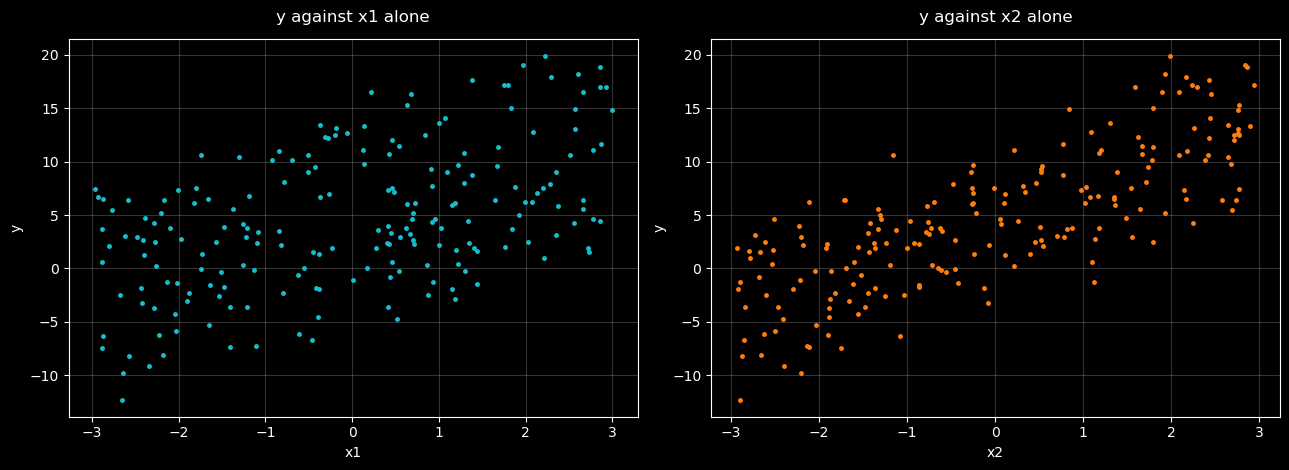

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(x1, y, ".", color="tab:cyan", markersize=5)
axes[0].set_xlabel("x1"); axes[0].set_ylabel("y")
axes[0].set_title("y against x1 alone", pad=12)

axes[1].plot(x2, y, ".", color="tab:orange", markersize=5)
axes[1].set_xlabel("x2"); axes[1].set_ylabel("y")
axes[1].set_title("y against x2 alone", pad=12)

for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Both scatter plots look loose. Neither feature alone explains $y$ well, because whichever one you
ignore is acting as unexplained scatter.

## 2. One at a time, then both

Fit three models and compare their $r^2$.

In [4]:
def fit(features, label=""):
    F = np.atleast_2d(features.T).T if features.ndim > 1 else features.reshape(-1, 1)
    model = LinearRegression().fit(F, y)
    pred = model.predict(F)
    sse = np.sum((y - pred)**2)
    sst = np.sum((y - y.mean())**2)
    return model, 1 - sse/sst, sse

m1, r2_1, sse_1 = fit(x1)
m2, r2_2, sse_2 = fit(x2)
m12, r2_12, sse_12 = fit(np.column_stack([x1, x2]))

print(f"{'model':<26} {'r^2':>8} {'SSE':>12}   coefficients")
print("-" * 74)
print(f"{'x1 alone':<26} {r2_1:8.4f} {sse_1:12.2f}   b1 = {m1.coef_[0]:+.4f}")
print(f"{'x2 alone':<26} {r2_2:8.4f} {sse_2:12.2f}   b2 = {m2.coef_[0]:+.4f}")
print(f"{'both x1 and x2':<26} {r2_12:8.4f} {sse_12:12.2f}   "
      f"b1 = {m12.coef_[0]:+.4f}, b2 = {m12.coef_[1]:+.4f}")
print("-" * 74)
print(f"{'the TRUE values':<26} {'':>8} {'':>12}   b1 = +2.0000, b2 = +3.0000")

model                           r^2          SSE   coefficients
--------------------------------------------------------------------------
x1 alone                     0.2505      6374.90   b1 = +1.9160
x2 alone                     0.6137      3285.85   b2 = +2.8974
both x1 and x2               0.9095       769.56   b1 = +2.0853, b2 = +3.0070
--------------------------------------------------------------------------
the TRUE values                                    b1 = +2.0000, b2 = +3.0000


Look at what happened. Each feature alone explains only a fraction of the variation; **together they
explain far more than the sum of their separate contributions**. And only the two-feature model
recovers the true coefficients, the single-feature fits are biased, because each is absorbing the
other's effect into its own residuals.

This is the case for multiple regression in one table.

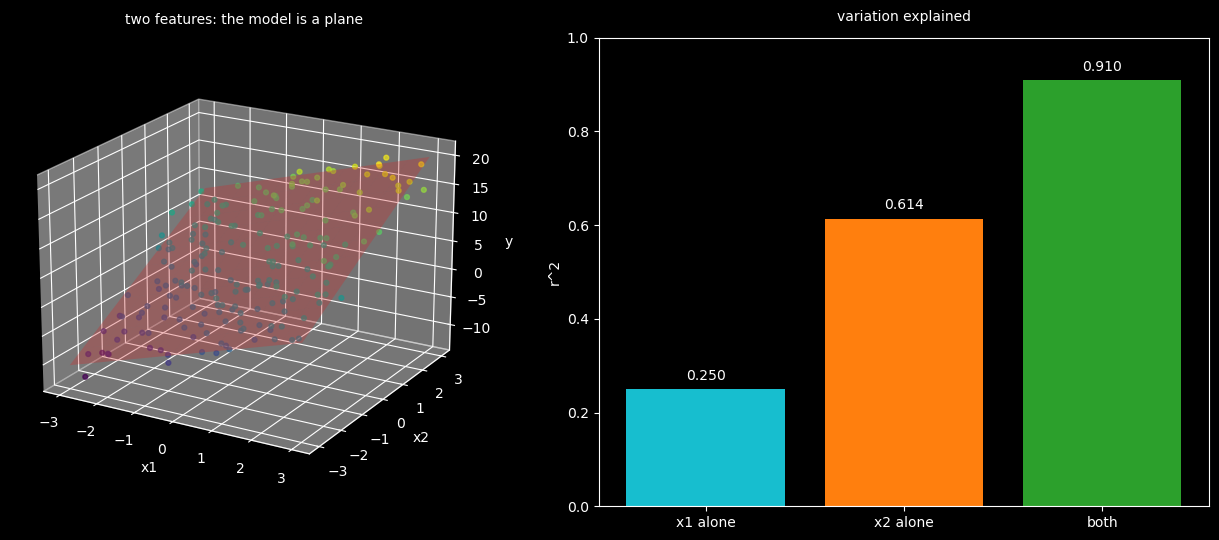

In [5]:
fig = plt.figure(figsize=(13, 5.5))

ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(x1, x2, y, c=y, cmap="viridis", s=12, alpha=0.7)
g1, g2 = np.meshgrid(np.linspace(-3, 3, 12), np.linspace(-3, 3, 12))
plane = m12.intercept_ + m12.coef_[0]*g1 + m12.coef_[1]*g2
ax.plot_surface(g1, g2, plane, alpha=0.3, color="tab:red")
ax.view_init(elev=20, azim=-60)
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_zlabel("y")
ax.set_title("two features: the model is a plane", pad=10, fontsize=10)

ax = fig.add_subplot(1, 2, 2)
ax.bar(["x1 alone", "x2 alone", "both"], [r2_1, r2_2, r2_12],
       color=["tab:cyan", "tab:orange", "tab:green"])
ax.set_ylabel("r^2")
ax.set_ylim(0, 1)
for i, v in enumerate([r2_1, r2_2, r2_12]):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)
ax.set_title("variation explained", pad=12, fontsize=10)

plt.tight_layout()
plt.show()

## 3. Coefficients mean something conditional

In the two-feature model, $b_1 \approx 2$ says: *increase $x_1$ by one unit, holding $x_2$ fixed, and
$\hat{y}$ rises by about 2.*

The "holding $x_2$ fixed" clause is doing real work. In the single-feature fit, $x_2$ was not held
fixed, it varied freely and its effect leaked into the residuals, which is why that coefficient was
off.

In [6]:
print("effect of a one-unit increase in x1:\n")
print(f"  from the x1-only model     : {m1.coef_[0]:+.4f}   (x2 left to vary)")
print(f"  from the two-feature model : {m12.coef_[0]:+.4f}   (x2 held fixed)")
print(f"  the true value             : +2.0000")
print()
base = np.array([[0.0, 0.0]])
step = np.array([[1.0, 0.0]])
print(f"predicted y at (x1, x2) = (0, 0): {m12.predict(base)[0]:.4f}")
print(f"predicted y at (x1, x2) = (1, 0): {m12.predict(step)[0]:.4f}")
print(f"difference: {m12.predict(step)[0] - m12.predict(base)[0]:.4f}  = b1, exactly")

effect of a one-unit increase in x1:

  from the x1-only model     : +1.9160   (x2 left to vary)
  from the two-feature model : +2.0853   (x2 held fixed)
  the true value             : +2.0000

predicted y at (x1, x2) = (0, 0): 4.7908
predicted y at (x1, x2) = (1, 0): 6.8761
difference: 2.0853  = b1, exactly


## 4. $r^2$ always rises: even for garbage

Here is the defect. Add a column of **pure random noise**, unrelated to $y$ by construction, and watch
$r^2$ go **up** anyway.

It has to. The fit could always assign the useless column a coefficient of zero and match the previous
model exactly; since it optimizes, it does at least that well. Any accidental alignment between the
noise and the residuals is then free improvement, on *this* data.

In [7]:
print(f"{'features':<40} {'r^2':>10}")
print("-" * 54)
print(f"{'x1, x2':<40} {r2_12:10.6f}")

feats = np.column_stack([x1, x2])
for k in range(1, 6):
    feats = np.column_stack([feats, np.random.normal(0, 1, n)])   # pure noise
    _, r2_k, _ = fit(feats)
    print(f"{'x1, x2 + %d column(s) of pure noise' % k:<40} {r2_k:10.6f}")
print("-" * 54)
print("Every added column raises r^2, and every one of them is meaningless.")

features                                        r^2
------------------------------------------------------
x1, x2                                     0.909522
x1, x2 + 1 column(s) of pure noise         0.911579
x1, x2 + 2 column(s) of pure noise         0.912923
x1, x2 + 3 column(s) of pure noise         0.913351
x1, x2 + 4 column(s) of pure noise         0.913364
x1, x2 + 5 column(s) of pure noise         0.914128
------------------------------------------------------
Every added column raises r^2, and every one of them is meaningless.


In [8]:
# the honest test: does the noise help on data the model has not seen?
from sklearn.model_selection import train_test_split

print(f"{'features':<34} {'train r^2':>11} {'TEST r^2':>11}")
print("-" * 58)
feats = np.column_stack([x1, x2])
for k in range(0, 6):
    if k > 0:
        feats = np.column_stack([feats, np.random.normal(0, 1, n)])
    Xtr, Xte, ytr, yte = train_test_split(feats, y, test_size=0.3, random_state=1)
    mdl = LinearRegression().fit(Xtr, ytr)
    print(f"{'x1, x2 + %d noise' % k:<34} {mdl.score(Xtr, ytr):11.4f} {mdl.score(Xte, yte):11.4f}")
print("-" * 58)
print("Training r^2 climbs steadily; TEST r^2 does not. The extra columns buy")
print("nothing on unseen data -- which is exactly what the train/test split is for.")

features                             train r^2    TEST r^2
----------------------------------------------------------
x1, x2 + 0 noise                        0.9061      0.9111
x1, x2 + 1 noise                        0.9061      0.9104
x1, x2 + 2 noise                        0.9074      0.9071
x1, x2 + 3 noise                        0.9078      0.9062
x1, x2 + 4 noise                        0.9110      0.9063
x1, x2 + 5 noise                        0.9112      0.9049
----------------------------------------------------------
Training r^2 climbs steadily; TEST r^2 does not. The extra columns buy
nothing on unseen data -- which is exactly what the train/test split is for.


This is the first sighting of **overfitting**: a model that looks better on the data it was fitted to
while being no better, or worse, on anything new. MSDS 550 and 565 spend a good deal of time on
detecting and preventing it. Here the lesson is narrower: **judge a feature on held-out data, not on
training $r^2$.**

## 5. Summary

- With several features the model is a **plane** (or a hyperplane), fitted by the same normal
  equations as before.
- Features can be worth far more **together** than separately; a single-feature fit absorbs the
  others' effects and gives biased coefficients.
- A coefficient means "the effect of this feature **holding the others fixed**."
- **$r^2$ never decreases when you add a feature**, even pure noise: so it cannot tell you whether a
  feature is worth having.
- Judge on **held-out data**. Training score going up while test score stays flat is **overfitting**.

Next: all of this on a real table of house sales, dozens of columns wide
(`U3-7_Regression-6_RealEstate`).